# Federated Image Classification with ResNet-18 Using Delta

In [2]:
!pip install torch torchvision -q

## Importing Required Libraries

This section imports the libraries required for building the Federated Learning pipeline.

The notebook mainly uses:

- PyTorch for deep learning
- Torchvision for datasets and transforms
- NumPy for numerical operations
- Matplotlib for plotting results

These libraries together help in model training, client simulation, and evaluation.

In [3]:

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18

from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import gc

## Configuring the Training Device

This cell checks whether CUDA is available.

If a GPU is detected, training is performed on the GPU; otherwise, the CPU is used.

Using a GPU significantly speeds up deep learning training, especially for convolutional neural networks like ResNet-18.

In [33]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Using Device: cuda
GPU: Tesla T4


## Defining Federated Learning Hyperparameters

This section defines the main training settings used throughout the experiment.

Some important parameters include:

- Number of clients
- Clients selected per round
- Number of communication rounds
- Local epochs
- Batch size
- Learning rate

These values directly affect convergence speed, communication cost, and overall model performance.

In [34]:
NUM_CLIENTS = 20

CLIENTS_PER_ROUND = 10

ROUNDS = 20

LOCAL_EPOCHS = 1

BATCH_SIZE = 16

LEARNING_RATE = 0.0003

ALPHA=0.5

## Applying Image Transformations

Before training, the images are preprocessed using augmentation and normalization techniques.

The training data uses:

- Random cropping
- Horizontal flipping
- Normalization

These transformations help improve generalization and reduce overfitting.

---

## Normalization

Pixel values are normalized using:   $x' = \frac{x - \mu}{\sigma}$


where:

- $\mu$ is the dataset mean
- $\sigma$ is the standard deviation

In [35]:
transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Loading the CIFAR-100 Dataset

## What this code does
This cell downloads and loads:
- Training dataset
- Testing dataset

using the CIFAR-100 dataset from Torchvision.

## About CIFAR-100
CIFAR-100 contains:
- 60,000 color images
- 100 different classes
- 32×32 image size

## Dataset Split
- 50,000 training images
- 10,000 testing images

## Why this dataset is used
CIFAR-100 is commonly used for:
- Image classification research
- Federated Learning experiments
- Deep learning benchmarking

Its large number of classes makes the learning task more challenging.

In [36]:
train_dataset = datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

print("Training Samples:", len(train_dataset))

print("Testing Samples:", len(test_dataset))

Training Samples: 50000
Testing Samples: 10000


## Creating Non-IID Client Datasets

In Federated Learning, client datasets are usually not identically distributed.

This section creates a Non-IID partition of CIFAR-100 across multiple clients.


### IID vs Non-IID Distribution

IID distribution assumes:  $P_k(x,y) = P(x,y)$


Non-IID distribution means: $P_k(x,y) \neq P_j(x,y)$

This means different clients may contain different class distributions.

For example:

- One client may mostly contain animal images
- Another may mostly contain vehicle images

This setup better reflects real-world decentralized data.

In [37]:
def dirichlet_split(
    dataset,
    num_clients,
    alpha=0.5
):

    labels = np.array(dataset.targets)

    num_classes = 100

    client_indices = [
        [] for _ in range(num_clients)
    ]

    for class_id in range(num_classes):

        class_indices = np.where(
            labels == class_id
        )[0]

        np.random.shuffle(class_indices)

        proportions = np.random.dirichlet(
            [alpha] * num_clients
        )

        proportions = (
            np.cumsum(proportions)
            * len(class_indices)
        ).astype(int)[:-1]

        split_indices = np.split(
            class_indices,
            proportions
        )

        for client_id in range(num_clients):

            client_indices[client_id].extend(
                split_indices[client_id]
            )

    return client_indices

# Generating Federated Clients

## What this code does
This cell creates all client datasets using the previously defined Non-IID partitioning function.

## Output
- 20 simulated clients are created
- Each client contains a different subset of CIFAR-100 classes

## Why this is important
Federated Learning requires:
- Multiple decentralized clients
- Independent local datasets

This step simulates distributed user data.

In [38]:
client_indices = dirichlet_split(
    train_dataset,
    NUM_CLIENTS,
    ALPHA
)

client_loaders = []

for client_id in range(NUM_CLIENTS):

    subset = Subset(
        train_dataset,
        client_indices[client_id]
    )

    loader = DataLoader(
        subset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    client_loaders.append(loader)

    print(
        f"Client {client_id} "
        f"has {len(subset)} samples"
    )

Client 0 has 2307 samples
Client 1 has 3056 samples
Client 2 has 2448 samples
Client 3 has 2261 samples
Client 4 has 2508 samples
Client 5 has 2895 samples
Client 6 has 2791 samples
Client 7 has 2310 samples
Client 8 has 2634 samples
Client 9 has 2540 samples
Client 10 has 2407 samples
Client 11 has 2626 samples
Client 12 has 2290 samples
Client 13 has 2529 samples
Client 14 has 2728 samples
Client 15 has 2287 samples
Client 16 has 2356 samples
Client 17 has 2328 samples
Client 18 has 1736 samples
Client 19 has 2963 samples


# Initializing the Global ResNet-18 Model

This section initializes the global model used for Federated Learning.

The architecture used is ResNet-18, which introduces residual connections to improve deep network training.

---

## Residual Learning

Instead of learning a direct mapping, ResNet learns: $H(x) = F(x) + x$

where:

- $F(x)$ is the residual mapping
- $x$ is the shortcut connection

These skip connections help reduce the vanishing gradient problem in deep neural networks.

In [39]:
global_model = resnet18(
    num_classes=100
).to(DEVICE)

print("Global Model Initialized")

Global Model Initialized


## Local Client Training

This function performs local optimization on a client's private dataset.

Each client updates the model weights independently using gradient descent.

---

## Local Weight Update

The parameter update rule is:

$\theta_{t+1}
=
\theta_t
-
\eta \nabla \mathcal{L}(\theta_t)$

where:

- $\eta$ is the learning rate
- $\mathcal{L}$ is the loss function
- $\nabla \mathcal{L}$ is the gradient

After local training, the client computes the weight difference relative to the received global model.

## Computing Delta Weights

Instead of sending the full model weights back to the server, each client sends only the weight updates.

This update is called the Delta Weight.

---

## Delta Weight Equation

The local update is computed as:

$\Delta w_k^{(t)}
=
w_k^{(t)}
-
w^{(t)}$

where:

- $w^{(t)}$ is the received global model
- $w_k^{(t)}$ is the locally trained client model
- $\Delta w_k^{(t)}$ represents the local weight update

This approach reduces redundant communication and focuses only on the learned changes.

In [44]:
def train_client(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=1,
        gamma=0.9
    )

    # Save initial global weights
    initial_weights = {
        key: value.clone()
        for key, value in model.state_dict().items()
    }

    model.train()

    total_loss = 0

    for epoch in range(LOCAL_EPOCHS):

        epoch_loss = 0

        # FIXED PART
        for batch in loader:

            images = batch[0].to(DEVICE)
            labels = batch[1].to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()

        avg_epoch_loss = (
            epoch_loss / len(loader)
        )

        total_loss += avg_epoch_loss

    avg_client_loss = (
        total_loss / LOCAL_EPOCHS
    )

    # Compute delta weights
    delta_weights = {}

    for key in model.state_dict():

        delta_weights[key] = (
            model.state_dict()[key]
            - initial_weights[key]
        )

    return delta_weights, avg_client_loss

## Aggregating Delta Updates

The server aggregates the received delta updates from multiple clients.

Instead of averaging full model weights, the server averages only the parameter changes.

---

## Delta Aggregation Equation

The global update becomes:

$w^{(t+1)}
=
w^{(t)}
+
\sum_{k=1}^{K}
\frac{n_k}{n}
\Delta w_k^{(t)}$

where:

- $\Delta w_k^{(t)}$ is the update from client $k$
- $n_k$ is the number of samples in client $k$
- $n$ is the total number of samples

This updates the global model using the aggregated learning signal from all selected clients.


In [41]:
def federated_average(client_deltas):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        avg_delta = torch.stack([
            client_deltas[i][key].float()
            for i in range(len(client_deltas))
        ], dim=0).mean(dim=0)

        # Add averaged delta
        global_dict[key] = (
            global_dict[key] + avg_delta
        )

    global_model.load_state_dict(global_dict)

    return global_model

## Evaluating the Global Model

This section evaluates the updated global model on the test dataset.

The model performance is measured using classification accuracy.


## Accuracy Formula

$\text{Accuracy}
=
\frac{\text{Correct Predictions}}
{\text{Total Samples}}
\times 100$

Higher accuracy indicates better generalization performance.

In [42]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return accuracy

# Federated Learning Training Process

This is the main communication loop of the Federated Learning system.

Each round consists of:

1. Selecting clients
2. Local training
3. Delta computation
4. Server aggregation
5. Global evaluation

---

## Global Update

The server updates the model using:

$w^{(t+1)}
=
w^{(t)}
+
\sum_{k=1}^{K}
\frac{n_k}{n}
\Delta w_k^{(t)}$

The updated global model is then broadcast back to clients for the next communication round.

In [45]:
round_accuracies = []
round_losses = []

best_accuracy = 0

best_model_weights = None

for round_num in range(ROUNDS):

    start_time = time.time()

    print("=" * 70)
    print(f"ROUND {round_num+1}/{ROUNDS}")
    print("=" * 70)

    selected_clients = np.random.choice(
        NUM_CLIENTS,
        CLIENTS_PER_ROUND,
        replace=False
    )

    print("Selected Clients:", selected_clients)

    client_deltas = []
    client_losses = []

    for client_id in selected_clients:

        print(f"\nTraining Client {client_id}...")

        local_model = resnet18(
            num_classes=100
        ).to(DEVICE)

        local_model.load_state_dict(
            global_model.state_dict()
        )

        client_dataset = Subset(
    train_dataset,
    client_indices[client_id]
)

        deltas, loss = train_client(
            local_model,
            client_dataset
        )
        client_deltas.append(deltas)
        client_losses.append(loss)

        print(
            f"Client {client_id} "
            f"Loss: {loss:.4f}"
        )

        del local_model

        torch.cuda.empty_cache()

        gc.collect()

    federated_average(client_deltas)

    avg_loss = (
        sum(client_losses)
        / len(client_losses)
    )

    accuracy = evaluate_model(global_model)

    round_accuracies.append(accuracy)

    round_losses.append(avg_loss)

    if round_num == 0:
        accuracy_change = accuracy
    else:
        accuracy_change = (
            accuracy
            - round_accuracies[-2]
        )

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model_weights = copy.deepcopy(
            global_model.state_dict()
        )

    round_time = (
        time.time() - start_time
    )

    print("\n" + "=" * 70)
    print("ROUND SUMMARY")
    print("=" * 70)

    print(
        f"Average Client Loss : "
        f"{avg_loss:.4f}"
    )

    print(
        f"Global Accuracy     : "
        f"{accuracy:.2f}%"
    )

    print(
        f"Accuracy Change     : "
        f"{accuracy_change:+.2f}%"
    )

    print(
        f"Best Accuracy       : "
        f"{best_accuracy:.2f}%"
    )

    print(
        f"Round Duration      : "
        f"{round_time:.2f} sec"
    )

    print("=" * 70)
    print()

ROUND 1/20
Selected Clients: [ 5 15 13 17  3 18  0  9 19 12]

Training Client 5...
Client 5 Loss: 3.5619

Training Client 15...
Client 15 Loss: 3.9545

Training Client 13...
Client 13 Loss: 3.8974

Training Client 17...
Client 17 Loss: 3.6671

Training Client 3...
Client 3 Loss: 3.7322

Training Client 18...
Client 18 Loss: 3.7261

Training Client 0...
Client 0 Loss: 3.9525

Training Client 9...
Client 9 Loss: 3.8604

Training Client 19...
Client 19 Loss: 3.7064

Training Client 12...
Client 12 Loss: 3.8352

ROUND SUMMARY
Average Client Loss : 3.7894
Global Accuracy     : 3.17%
Accuracy Change     : +3.17%
Best Accuracy       : 3.17%
Round Duration      : 40.47 sec

ROUND 2/20
Selected Clients: [ 8  2  0  4 14 11 18 10 17 12]

Training Client 8...
Client 8 Loss: 3.7430

Training Client 2...
Client 2 Loss: 3.5470

Training Client 0...
Client 0 Loss: 3.7950

Training Client 4...
Client 4 Loss: 3.7034

Training Client 14...
Client 14 Loss: 3.7277

Training Client 11...
Client 11 Loss: 3.6

In [47]:
global_model.load_state_dict(
    best_model_weights
)

print("Best Model Restored")

print(
    f"Best Accuracy: "
    f"{best_accuracy:.2f}%"
)

Best Model Restored
Best Accuracy: 26.34%


## Visualizing Global Accuracy

This graph shows how the global model accuracy changes over communication rounds.

An increasing accuracy trend generally indicates improved collaborative learning across clients.

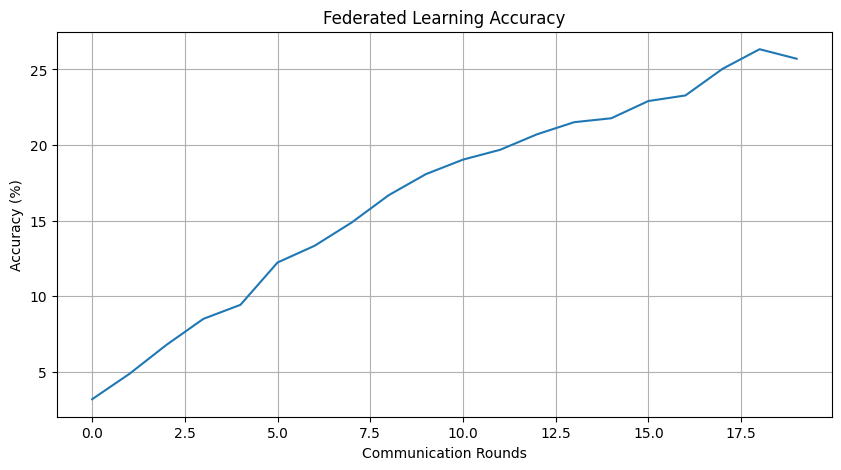

In [48]:
plt.figure(figsize=(10,5))

plt.plot(round_accuracies)

plt.xlabel("Communication Rounds")

plt.ylabel("Accuracy (%)")

plt.title(
    "Federated Learning Accuracy"
)

plt.grid(True)

plt.show()

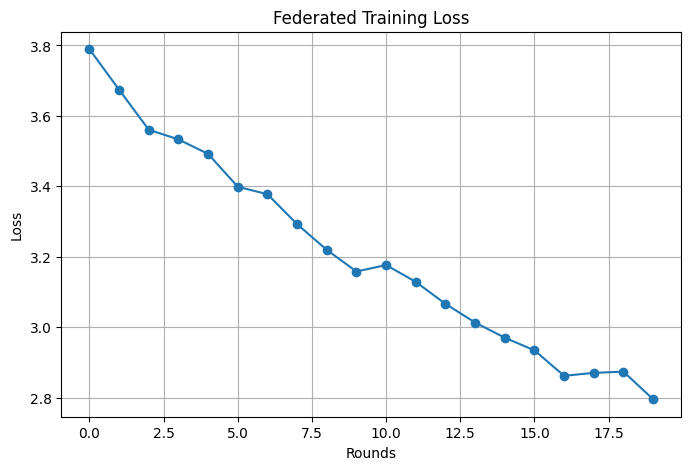

In [49]:
import matplotlib.pyplot as plt

# -------------------------------
# LOSS GRAPH
# -------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    round_losses,
    marker='o'
)

plt.title("Federated Training Loss")

plt.xlabel("Rounds")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

# Conclusion

The federated learning model showed consistent improvement over 20 communication rounds. Global accuracy increased from 3.17% in Round 1 to a peak of 26.34% in Round 19, while the average client loss decreased from 3.79 to 2.80. This inverse relationship between accuracy and loss indicates that the model successfully learned useful feature representations across distributed clients. Although a slight drop in accuracy was observed in the final round (25.71%), the overall trend demonstrates stable convergence and effective aggregation of client updates. The results confirm that the FedAvg-based training process improved model performance over successive communication rounds.